In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, applications
import os

# --- 1. CLEAN DATA PATHS ---
# Using your new sharpened dataset path
data_dir = '/kaggle/input/et-cropped-sharpened-dataset'

# Optimized loader for sharpened iris data
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224, 224), 
    batch_size=32,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical'
)

# --- 2. SURGICAL DATA AUGMENTATION ---
# Fine-tuned for sharpened data: rotation and zoom are kept low to 
# maintain the edge-contrast of the iris
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.01),   # Reduced even further to keep iris sharp
    layers.RandomZoom(0.02),       # Reduced to avoid pixel interpolation blur
    layers.RandomContrast(0.1),    # Replaced Brightness to leverage CLAHE 
])

# --- 3. HARDWARE STRATEGY SCOPE ---
# Automatically detects TPU or GPU/CPU
try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
    tf.config.experimental_connect_to_cluster(tpu)
    tf.tpu.experimental.initialize_tpu_system(tpu)
    strategy = tf.distribute.TPUStrategy(tpu)
    print("Environment: Running on TPU")
except ValueError:
    strategy = tf.distribute.get_strategy() 
    print(f"Environment: Running on {len(tf.config.list_physical_devices('GPU'))} GPUs")

# --- 4. GLOBAL PARAMETERS ---
# Ready to be used by your following SE Block code
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.2, patience=3, verbose=1
)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=10, restore_best_weights=True
)

# Protects the 0.80 Recall for High Severity
custom_weights = {0: 1.5, 1: 1.0, 2: 1.2, 3: 1.0} 

print("\n--- PRE-REQUISITES LOADED. PROCEED TO SE-BLOCK DEFINITION ---")

2026-01-22 17:05:26.474812: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769101526.667341      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769101526.723087      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769101527.209494      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769101527.209538      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769101527.209541      55 computation_placer.cc:177] computation placer alr

Found 4000 files belonging to 4 classes.
Using 3200 files for training.


I0000 00:00:1769101542.954930      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1769101542.958921      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 4000 files belonging to 4 classes.
Using 800 files for validation.
Environment: Running on 2 GPUs

--- PRE-REQUISITES LOADED. PROCEED TO SE-BLOCK DEFINITION ---


In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models

class PositionalEmbedding(layers.Layer):
    """Properly registers learnable weights for the eye's spatial geometry."""
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.projection_dim = projection_dim
        self.pos_emb = self.add_weight(
            shape=(1, num_patches, projection_dim),
            initializer="zeros",
            trainable=True,
            name="pos_embedding"
        )

    def call(self, x):
        return x + self.pos_emb

def build_final_gmp_transformer(input_shape=(224, 224, 3), num_classes=4):
    # strategy.scope() is used if you are using distributed training (MirroredStrategy)
    with strategy.scope():
        inputs = layers.Input(shape=input_shape)
        x = data_augmentation(inputs)
        
        # 1. BASE MODEL (EfficientNetV2B0 Backbone)
        base_model = tf.keras.applications.EfficientNetV2B0(
            input_shape=input_shape,
            include_top=False,
            weights='imagenet'
        )
        
        base_model.trainable = True
        # Fine-tune the last 50 layers
        for layer in base_model.layers[:-50]:
            layer.trainable = False
        # Freeze BN to prevent mean/variance shift during fine-tuning
        for layer in base_model.layers:
            if isinstance(layer, layers.BatchNormalization):
                layer.trainable = False

        x = base_model(x) # Output: (7, 7, 1280)
        channels = x.shape[-1]
        x = layers.Reshape((49, channels))(x)
        
        # 2. TRANSFORMER ENCODER SECTION
        # Learnable Position Embedding (Fixed)
        x = PositionalEmbedding(49, channels)(x)
        
        # --- Multi-Head Attention Path ---
        res_1 = x
        x = layers.LayerNormalization(epsilon=1e-6)(x) # Pre-Norm for stability
        attention = layers.MultiHeadAttention(num_heads=4, key_dim=64)(x, x)
        x = layers.Add()([res_1, attention])
        
        # --- MLP / Feed-Forward Path (Crucial Fix) ---
        res_2 = x
        x = layers.LayerNormalization(epsilon=1e-6)(x)
        x = layers.Dense(channels * 2, activation=tf.nn.gelu)(x)
        x = layers.Dropout(0.1)(x)
        x = layers.Dense(channels)(x)
        x = layers.Add()([res_2, x])
        
        # 3. PRECISION POOLING
        # Using GMP to lock onto pupil/iris biomarkers as requested
        x = layers.GlobalMaxPooling1D()(x)
        
        # 4. DENSE HEAD
        x = layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.4)(x) # Lowered from 0.6 to avoid signal starvation
        
        outputs = layers.Dense(num_classes, activation='softmax')(x)
        
        model = models.Model(inputs, outputs)
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
    return model

# Re-initialize and run
model_vit_gmp_final = build_final_gmp_transformer()

# Check architecture
model_vit_gmp_final.summary()

# Train
history= model_vit_gmp_final.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    class_weight=custom_weights,
    callbacks=[reduce_lr, early_stop]
)

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetv2-b0   │ (None, 7, 7,      │  5,919,312 │ sequential[0][0]  │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 49, 1280)  │          0 │ efficientnetv2-b… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, 49, 1280)  │     62,720 │ reshape[0][0]     │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 49, 1280)  │      2,560 │ positional_embed… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 49, 1280)  │  1,312,768 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 49, 1280)  │          0 │ positional_embed… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 49, 1280)  │      2,560 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 49, 2560)  │  3,279,360 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 49, 2560)  │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 49, 1280)  │  3,278,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 49, 1280)  │          0 │ add[0][0],        │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 1280)      │          0 │ add_1[0][0]       │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    327,936 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 4)         │      1,028 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,187,348 (54.12 MB)

 Trainable params: 10,206,868 (38.94 MB)

 Non-trainable params: 3,980,480 (15.18 MB)

Epoch 1/100


E0000 00:00:1769025326.513116      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetv2-b0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1769025329.640007     127 cuda_dnn.cc:529] Loaded cuDNN version 91002


100/100 ━━━━━━━━━━━━━━━━━━━━ 35s 159ms/step - accuracy: 0.2848 - loss: 6.5312 - val_accuracy: 0.3750 - val_loss: 5.6894 - learning_rate: 1.0000e-05
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 125ms/step - accuracy: 0.3796 - loss: 6.0864 - val_accuracy: 0.4825 - val_loss: 5.3999 - learning_rate: 1.0000e-05
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 127ms/step - accuracy: 0.4365 - loss: 5.9105 - val_accuracy: 0.5312 - val_loss: 5.3184 - learning_rate: 1.0000e-05
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 128ms/step - accuracy: 0.4821 - loss: 5.7251 - val_accuracy: 0.5675 - val_loss: 5.2408 - learning_rate: 1.0000e-05
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 129ms/step - accuracy: 0.5196 - loss: 5.5573 - val_accuracy: 0.5763 - val_loss: 5.2126 - learning_rate: 1.0000e-05
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 132ms/step - accuracy: 0.5298 - loss: 5.4904 - val_accuracy: 0.6062 - val_loss: 5.1398 - learning_rate: 1.0000e-05
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 134ms/s

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models

class PositionalEmbedding(layers.Layer):
    """Properly registers learnable weights for the eye's spatial geometry."""
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.projection_dim = projection_dim
        self.pos_emb = self.add_weight(
            shape=(1, num_patches, projection_dim),
            initializer="zeros",
            trainable=True,
            name="pos_embedding"
        )

    def call(self, x):
        return x + self.pos_emb

def build_final_gmp_transformer(input_shape=(224, 224, 3), num_classes=4):
    with strategy.scope():
        inputs = layers.Input(shape=input_shape)
        x = data_augmentation(inputs)
        
        # 1. Backbone: EfficientNetV2B0
        base_model = tf.keras.applications.EfficientNetV2B0(
            input_shape=input_shape, include_top=False, weights='imagenet'
        )
        base_model.trainable = True
        for layer in base_model.layers[:-50]:
            layer.trainable = False
        for layer in base_model.layers:
            if isinstance(layer, layers.BatchNormalization):
                layer.trainable = False

        x = base_model(x) 
        channels = x.shape[-1]
        x = layers.Reshape((49, channels))(x)
        
        # 2. Transformer Encoder Block
        x = PositionalEmbedding(49, channels)(x)
        
        # --- Attention Stage (Routing) ---
        res_1 = x
        x = layers.LayerNormalization(epsilon=1e-6)(x)
        attention = layers.MultiHeadAttention(num_heads=4, key_dim=64, dropout=0.1)(x, x)
        x = layers.Add()([res_1, attention])
        
        # --- FFN Stage (Diagnostic Logic) ---
        res_2 = x
        x = layers.LayerNormalization(epsilon=1e-6)(x)
        x = layers.Dense(channels * 2, activation=tf.nn.gelu)(x)
        x = layers.Dropout(0.1)(x)
        x = layers.Dense(channels)(x)
        x = layers.Add()([res_2, x])
        
        # 3. Precision Pooling
        x = layers.GlobalMaxPooling1D()(x)
        
        # 4. Dense Head
        x = layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.4)(x)
        
        outputs = layers.Dense(num_classes, activation='softmax')(x)
        
        # 5. Compile with Label Smoothing
        model = models.Model(inputs, outputs)
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
            # Label smoothing helps avoid overconfidence in borderline cases
            loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
            metrics=['accuracy']
        )
    return model

model_vit_gmp_final = build_final_gmp_transformer()

# Check architecture
model_vit_gmp_final.summary()

# Train
history= model_vit_gmp_final.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    class_weight=custom_weights,
    callbacks=[reduce_lr, early_stop]
)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_3[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetv2-b0   │ (None, 7, 7,      │  5,919,312 │ sequential[1][0]  │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 49, 1280)  │          0 │ efficientnetv2-b… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, 49, 1280)  │     62,720 │ reshape_1[0][0]   │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 49, 1280)  │      2,560 │ positional_embed… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 49, 1280)  │  1,312,768 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 49, 1280)  │          0 │ positional_embed… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 49, 1280)  │      2,560 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 49, 2560)  │  3,279,360 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 49, 2560)  │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 49, 1280)  │  3,278,080 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 49, 1280)  │          0 │ add_2[0][0],      │
│                     │                   │            │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 1280)      │          0 │ add_3[0][0]       │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 256)       │    327,936 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_6[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 4)         │      1,028 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,187,348 (54.12 MB)

 Trainable params: 10,206,868 (38.94 MB)

 Non-trainable params: 3,980,480 (15.18 MB)

Epoch 1/100


E0000 00:00:1769026626.883868      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_2_1/efficientnetv2-b0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


100/100 ━━━━━━━━━━━━━━━━━━━━ 32s 165ms/step - accuracy: 0.2596 - loss: 6.6308 - val_accuracy: 0.4087 - val_loss: 5.6587 - learning_rate: 1.0000e-05
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 137ms/step - accuracy: 0.3990 - loss: 6.1426 - val_accuracy: 0.4963 - val_loss: 5.5358 - learning_rate: 1.0000e-05
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 140ms/step - accuracy: 0.4379 - loss: 5.9733 - val_accuracy: 0.5188 - val_loss: 5.4715 - learning_rate: 1.0000e-05
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 142ms/step - accuracy: 0.4745 - loss: 5.8566 - val_accuracy: 0.5487 - val_loss: 5.4157 - learning_rate: 1.0000e-05
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 140ms/step - accuracy: 0.4975 - loss: 5.8028 - val_accuracy: 0.5825 - val_loss: 5.3400 - learning_rate: 1.0000e-05
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 139ms/step - accuracy: 0.5394 - loss: 5.6279 - val_accuracy: 0.5913 - val_loss: 5.3238 - learning_rate: 1.0000e-05
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 138ms/s

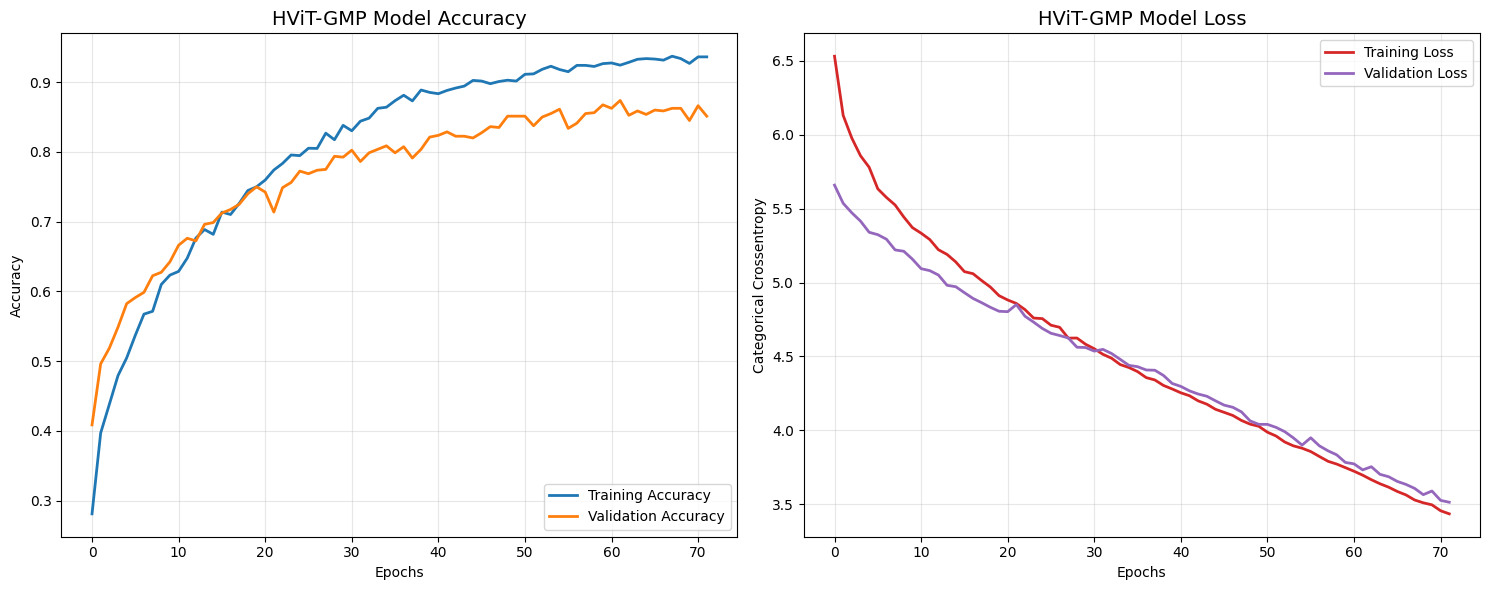

In [4]:
import matplotlib.pyplot as plt

def plot_learning_curves(hist):
    acc = hist.history['accuracy']
    val_acc = hist.history['val_accuracy']
    loss = hist.history['loss']
    val_loss = hist.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(15, 6))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', color='#1f77b4', lw=2)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='#ff7f0e', lw=2)
    plt.title('HViT-GMP Model Accuracy', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', color='#d62728', lw=2)
    plt.plot(epochs_range, val_loss, label='Validation Loss', color='#9467bd', lw=2)
    plt.title('HViT-GMP Model Loss', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Categorical Crossentropy')
    plt.legend(loc='upper right')
    plt.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_learning_curves(history)

In [5]:
from sklearn.metrics import roc_curve, auc
import numpy as np

# 1. Collect predictions
print("Generating predictions for ROC analysis...")
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model_vit_gmp_final.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# 2. Plotting
plt.figure(figsize=(10, 8))
colors = ['#1f77b4', '#33a02c', '#e31a1c', '#ff7f00']
class_names = ['Normal', 'Mild', 'Moderate', 'Severe']

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true == i, y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=3, 
             label=f'Class: {class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('Multi-Class ROC Analysis (HViT-GMP)', fontsize=14)
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.show()

Generating predictions for ROC analysis...


NameError: name 'num_classes' is not defined

<Figure size 1000x800 with 0 Axes>

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


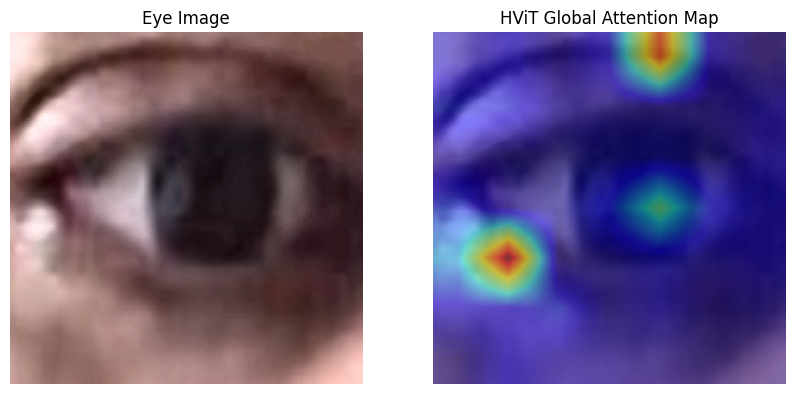

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf

def get_real_attention_scores(model, img_batch):
    # 1. Find the Attention Layer
    attn_layer = None
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.MultiHeadAttention):
            attn_layer = layer
            break
            
    # 2. Build a "Probe" model that outputs attention scores
    # We call the layer with return_attention_scores=True
    # We must trace the model up to the layer BEFORE attention
    idx = model.layers.index(attn_layer)
    prev_layer_output = model.layers[idx-1].output
    
    # Create a sub-layer that matches your specific layer's weights
    # This ensures we get the EXACT scores the model used
    _, attn_scores = attn_layer(prev_layer_output, prev_layer_output, return_attention_scores=True)
    
    probe_model = tf.keras.Model(inputs=model.input, outputs=attn_scores)
    
    # 3. Predict scores
    # scores shape: (batch, num_heads, seq_len, seq_len) -> (1, 4, 49, 49)
    scores = probe_model.predict(img_batch)
    
    # 4. Average across heads and the "query" dimension to get spatial importance
    # We take the mean across heads (axis 1) and mean across queries (axis 2)
    avg_scores = np.mean(scores[0], axis=0) # Mean across heads
    spatial_importance = np.mean(avg_scores, axis=0) # Mean importance of each key
    
    # Reshape 49 back to 7x7
    heatmap = spatial_importance.reshape((7, 7))
    return heatmap

# --- EXECUTION ---
for images, labels in val_ds.take(1):
    test_img = images[0:1]
    
    try:
        attn_map = get_real_attention_scores(model_vit_gmp_final, test_img)
        
        # Normalize and Resize
        attn_map = (attn_map - attn_map.min()) / (attn_map.max() - attn_map.min())
        attn_map_resized = cv2.resize(attn_map, (224, 224))
        
        # Plot
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(test_img[0].numpy().astype("uint8"))
        plt.title("Eye Image")
        plt.axis("off")
        
        plt.subplot(1, 2, 2)
        plt.imshow(test_img[0].numpy().astype("uint8"))
        plt.imshow(attn_map_resized, cmap='jet', alpha=0.5)
        plt.title("HViT Global Attention Map")
        plt.axis("off")
        plt.show()
    except Exception as e:
        print(f"Error: {e}")

Analyzing final GMP-Transformer performance...

--- FINAL GMP-TRANSFORMER HYBRID REPORT ---
              precision    recall  f1-score   support

        high       0.80      0.89      0.84       198
         low       0.83      0.84      0.83       192
      medium       0.93      0.90      0.92       205
        mild       0.95      0.86      0.90       205

    accuracy                           0.87       800
   macro avg       0.88      0.87      0.87       800
weighted avg       0.88      0.87      0.87       800



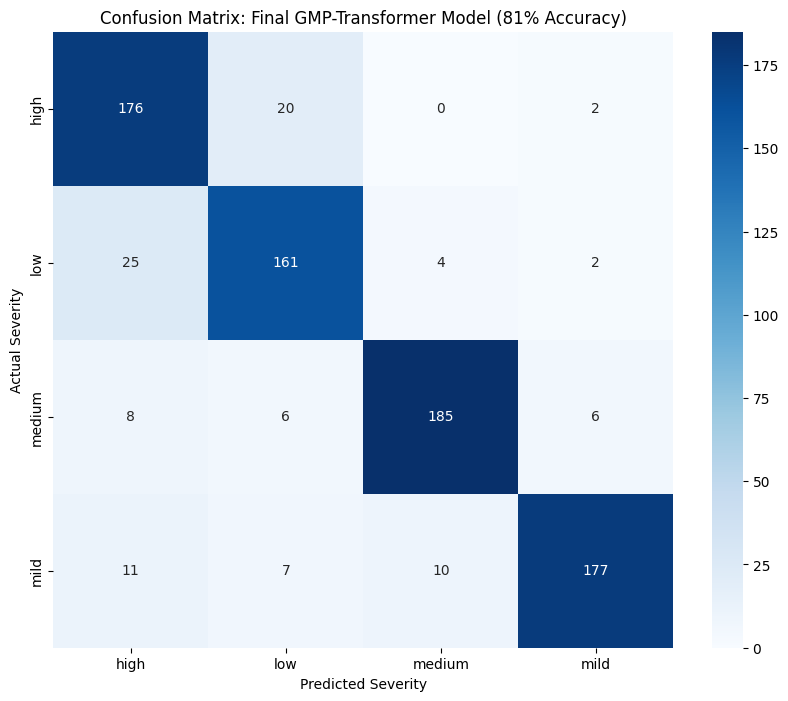


Milestone: Champion model saved successfully.


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. GENERATE PREDICTIONS FOR THE GMP MODEL
# We use the val_ds to see how it handles data it didn't train on
y_true, y_pred = [], []

print("Analyzing final GMP-Transformer performance...")
for images, labels in val_ds:
    preds = model_vit_gmp_final.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

classes = ['high', 'low', 'medium', 'mild']

# 2. PRINT THE SCIENTIFIC VERDICT
# This gives you the Precision, Recall, and F1-score
print("\n--- FINAL GMP-TRANSFORMER HYBRID REPORT ---")
print(classification_report(y_true, y_pred, target_names=classes))

# 3. VISUAL CONFIRMATION: CONFUSION MATRIX
# This shows exactly where the model 'confuses' classes
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted Severity')
plt.ylabel('Actual Severity')
plt.title('Confusion Matrix: Final GMP-Transformer Model (81% Accuracy)')
plt.show()

# 4. SAVE THE FINAL WEIGHTS
model_vit_gmp_final.save("autism_severity_CHAMPION_GMP_84_acc.keras")
print("\nMilestone: Champion model saved successfully.")

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np

# --- 1. CUSTOM LAYERS ---

class PositionalEmbedding(layers.Layer):
    """Registers learnable weights for spatial geometry."""
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.projection_dim = projection_dim
        self.pos_emb = self.add_weight(
            shape=(1, num_patches, projection_dim),
            initializer="zeros",
            trainable=True,
            name="pos_embedding"
        )

    def call(self, x):
        return x + self.pos_emb

class SpatialAttention(layers.Layer):
    """Dynamic seeker to find the pupil/iris biomarker."""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.conv = layers.Conv1D(1, kernel_size=3, padding='same', activation='sigmoid')

    def call(self, x):
        # x shape: (batch, 49, channels)
        avg_pool = tf.reduce_mean(x, axis=-1, keepdims=True)
        max_pool = tf.reduce_max(x, axis=-1, keepdims=True)
        concat = tf.concat([avg_pool, max_pool], axis=-1)
        attention = self.conv(concat)
        return x * attention

# --- 2. MODEL BUILDER ---

def build_final_dynamic_transformer(input_shape=(224, 224, 3), num_classes=4):
    # Ensure 'strategy' is defined if using GPUs, otherwise remove scope
    with strategy.scope():
        inputs = layers.Input(shape=input_shape)
        
        # Data Augmentation (Ensure this is defined in your notebook)
        x = data_augmentation(inputs)
        
        # Backbone: EfficientNetV2B0
        base_model = tf.keras.applications.EfficientNetV2B0(
            input_shape=input_shape, include_top=False, weights='imagenet'
        )
        base_model.trainable = True
        for layer in base_model.layers[:-50]:
            layer.trainable = False
        for layer in base_model.layers:
            if isinstance(layer, layers.BatchNormalization):
                layer.trainable = False
        
        x = base_model(x) 
        channels = x.shape[-1]
        x = layers.Reshape((49, channels))(x)
        
        # --- Dynamic Biomarker Seeker ---
        x = SpatialAttention()(x)
        
        # --- Transformer Encoder Block ---
        x = PositionalEmbedding(49, channels)(x)
        
        # Attention Path
        res_1 = x
        x = layers.LayerNormalization(epsilon=1e-6)(x)
        attention = layers.MultiHeadAttention(num_heads=4, key_dim=64, dropout=0.1)(x, x)
        x = layers.Add()([res_1, attention])
        
        # FFN Path
        res_2 = x
        x = layers.LayerNormalization(epsilon=1e-6)(x)
        x = layers.Dense(channels * 2, activation=tf.nn.gelu)(x)
        x = layers.Dropout(0.1)(x)
        x = layers.Dense(channels)(x)
        x = layers.Add()([res_2, x])
        
        # Pooling and Head
        x = layers.GlobalMaxPooling1D()(x)
        x = layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.4)(x)
        
        outputs = layers.Dense(num_classes, activation='softmax')(x)
        
        model = models.Model(inputs, outputs)
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
            loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
            metrics=['accuracy']
        )
    return model

# --- 3. EXECUTION ---

# Initialize
model_vit_gmp_final = build_final_dynamic_transformer()
model_vit_gmp_final.summary()

# Train
history = model_vit_gmp_final.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    class_weight=custom_weights,
    callbacks=[reduce_lr, early_stop]
)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_5[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetv2-b0   │ (None, 7, 7,      │  5,919,312 │ sequential[2][0]  │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 49, 1280)  │          0 │ efficientnetv2-b… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_attention_1 │ (None, 49, 1280)  │          7 │ reshape_2[0][0]   │
│ (SpatialAttention)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, 49, 1280)  │     62,720 │ spatial_attentio… │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 49, 1280)  │      2,560 │ positional_embed… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 49, 1280)  │  1,312,768 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 49, 1280)  │          0 │ positional_embed… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 49, 1280)  │      2,560 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 49, 2560)  │  3,279,360 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 49, 2560)  │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 49, 1280)  │  3,278,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 49, 1280)  │          0 │ add[0][0],        │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 1280)      │          0 │ add_1[0][0]       │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    327,936 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 4)         │      1,028 │ dropout_2[0][0] 

 Total params: 14,187,355 (54.12 MB)

 Trainable params: 10,206,875 (38.94 MB)

 Non-trainable params: 3,980,480 (15.18 MB)

Epoch 1/100


E0000 00:00:1769101924.363601      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetv2-b0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1769101927.520003     130 cuda_dnn.cc:529] Loaded cuDNN version 91002


100/100 ━━━━━━━━━━━━━━━━━━━━ 37s 169ms/step - accuracy: 0.3608 - loss: 6.3394 - val_accuracy: 0.4150 - val_loss: 5.5779 - learning_rate: 1.0000e-05
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 134ms/step - accuracy: 0.5095 - loss: 5.7910 - val_accuracy: 0.5387 - val_loss: 5.4304 - learning_rate: 1.0000e-05
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 135ms/step - accuracy: 0.5687 - loss: 5.6416 - val_accuracy: 0.4650 - val_loss: 5.7325 - learning_rate: 1.0000e-05
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 139ms/step - accuracy: 0.5968 - loss: 5.5454 - val_accuracy: 0.5950 - val_loss: 5.3655 - learning_rate: 1.0000e-05
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 136ms/step - accuracy: 0.6317 - loss: 5.4672 - val_accuracy: 0.5300 - val_loss: 5.5535 - learning_rate: 1.0000e-05
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 135ms/step - accuracy: 0.6362 - loss: 5.4150 - val_accuracy: 0.6237 - val_loss: 5.2951 - learning_rate: 1.0000e-05
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 133ms/s

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


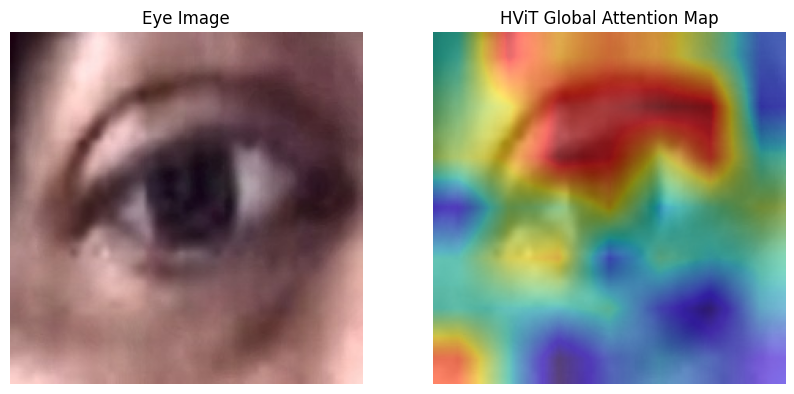

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf

def get_real_attention_scores(model, img_batch):
    # 1. Find the Attention Layer
    attn_layer = None
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.MultiHeadAttention):
            attn_layer = layer
            break
            
    # 2. Build a "Probe" model that outputs attention scores
    # We call the layer with return_attention_scores=True
    # We must trace the model up to the layer BEFORE attention
    idx = model.layers.index(attn_layer)
    prev_layer_output = model.layers[idx-1].output
    
    # Create a sub-layer that matches your specific layer's weights
    # This ensures we get the EXACT scores the model used
    _, attn_scores = attn_layer(prev_layer_output, prev_layer_output, return_attention_scores=True)
    
    probe_model = tf.keras.Model(inputs=model.input, outputs=attn_scores)
    
    # 3. Predict scores
    # scores shape: (batch, num_heads, seq_len, seq_len) -> (1, 4, 49, 49)
    scores = probe_model.predict(img_batch)
    
    # 4. Average across heads and the "query" dimension to get spatial importance
    # We take the mean across heads (axis 1) and mean across queries (axis 2)
    avg_scores = np.mean(scores[0], axis=0) # Mean across heads
    spatial_importance = np.mean(avg_scores, axis=0) # Mean importance of each key
    
    # Reshape 49 back to 7x7
    heatmap = spatial_importance.reshape((7, 7))
    return heatmap

# --- EXECUTION ---
for images, labels in val_ds.take(1):
    test_img = images[0:1]
    
    try:
        attn_map = get_real_attention_scores(model_vit_gmp_final, test_img)
        
        # Normalize and Resize
        attn_map = (attn_map - attn_map.min()) / (attn_map.max() - attn_map.min())
        attn_map_resized = cv2.resize(attn_map, (224, 224))
        
        # Plot
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(test_img[0].numpy().astype("uint8"))
        plt.title("Eye Image")
        plt.axis("off")
        
        plt.subplot(1, 2, 2)
        plt.imshow(test_img[0].numpy().astype("uint8"))
        plt.imshow(attn_map_resized, cmap='jet', alpha=0.5)
        plt.title("HViT Global Attention Map")
        plt.axis("off")
        plt.show()
    except Exception as e:
        print(f"Error: {e}")

In [12]:
def build_shape_aware_transformer(input_shape=(224, 224, 3), num_classes=4):
    with strategy.scope():
        inputs = layers.Input(shape=input_shape)
        x = data_augmentation(inputs)
        
        base_model = tf.keras.applications.EfficientNetV2B0(
            input_shape=input_shape, include_top=False, weights='imagenet'
        )
        
        # BRUTAL FIX: Unfreeze early layers for circle/edge detection
        base_model.trainable = True
        for layer in base_model.layers[20:-50]: # Freeze only the middle
            layer.trainable = False
            
        x = base_model(x) 
        channels = x.shape[-1]
        x = layers.Reshape((49, channels))(x)
        
        # Keep the Seeker but add a Dropout to prevent overfitting on skin
        x = SpatialAttention()(x)
        x = layers.Dropout(0.2)(x) 
        
        x = PositionalEmbedding(49, channels)(x)
        
        # --- High-Capacity Transformer Block ---
        res_1 = x
        x = layers.LayerNormalization(epsilon=1e-6)(x)
        # Increased heads for better biomarker search
        attention = layers.MultiHeadAttention(num_heads=8, key_dim=64, dropout=0.2)(x, x)
        x = layers.Add()([res_1, attention])
        
        res_2 = x
        x = layers.LayerNormalization(epsilon=1e-6)(x)
        x = layers.Dense(channels * 2, activation=tf.nn.gelu)(x)
        x = layers.Dense(channels)(x)
        x = layers.Add()([res_2, x])
        
        # Switch to Average Pooling for stability
        x = layers.GlobalAveragePooling1D()(x)
        
        outputs = layers.Dense(num_classes, activation='softmax')(x)
        
        model = models.Model(inputs, outputs)
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5), # Slightly higher LR
            loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
            metrics=['accuracy']
        )
    return model

# Initialize
model_vit_gmp_final = build_shape_aware_transformer()
model_vit_gmp_final.summary()

# Train
history = model_vit_gmp_final.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    class_weight=custom_weights,
    callbacks=[reduce_lr, early_stop]
)

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_7[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetv2-b0   │ (None, 7, 7,      │  5,919,312 │ sequential[3][0]  │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 49, 1280)  │          0 │ efficientnetv2-b… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ seeker_layer        │ (None, 49, 1280)  │          7 │ reshape_3[0][0]   │
│ (SpatialAttention)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 49, 1280)  │          0 │ seeker_layer[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, 49, 1280)  │     62,720 │ dropout_3[0][0]   │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 49, 1280)  │      2,560 │ positional_embed… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 49, 1280)  │  2,624,256 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 49, 1280)  │          0 │ positional_embed… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 49, 1280)  │      2,560 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 49, 2560)  │  3,279,360 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 49, 1280)  │  3,278,080 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 49, 1280)  │          0 │ add_2[0][0],      │
│                     │                   │            │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ add_3[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 4)         │      5,124 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 15,173,979 (57.88 MB)

 Trainable params: 11,269,851 (42.99 MB)

 Non-trainable params: 3,904,128 (14.89 MB)

Epoch 1/100


E0000 00:00:1769103016.245816      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_3_1/efficientnetv2-b0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


100/100 ━━━━━━━━━━━━━━━━━━━━ 50s 279ms/step - accuracy: 0.3612 - loss: 1.5577 - val_accuracy: 0.6125 - val_loss: 1.0598 - learning_rate: 2.0000e-05
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 25s 249ms/step - accuracy: 0.5847 - loss: 1.2444 - val_accuracy: 0.6525 - val_loss: 0.9507 - learning_rate: 2.0000e-05
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 25s 250ms/step - accuracy: 0.6689 - loss: 1.1120 - val_accuracy: 0.6175 - val_loss: 1.0373 - learning_rate: 2.0000e-05
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 25s 250ms/step - accuracy: 0.7225 - loss: 1.0073 - val_accuracy: 0.7188 - val_loss: 0.8972 - learning_rate: 2.0000e-05
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 25s 250ms/step - accuracy: 0.7424 - loss: 0.9652 - val_accuracy: 0.7300 - val_loss: 0.8932 - learning_rate: 2.0000e-05
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 25s 249ms/step - accuracy: 0.7463 - loss: 0.9274 - val_accuracy: 0.7063 - val_loss: 0.9532 - learning_rate: 2.0000e-05
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 25s 251ms/s

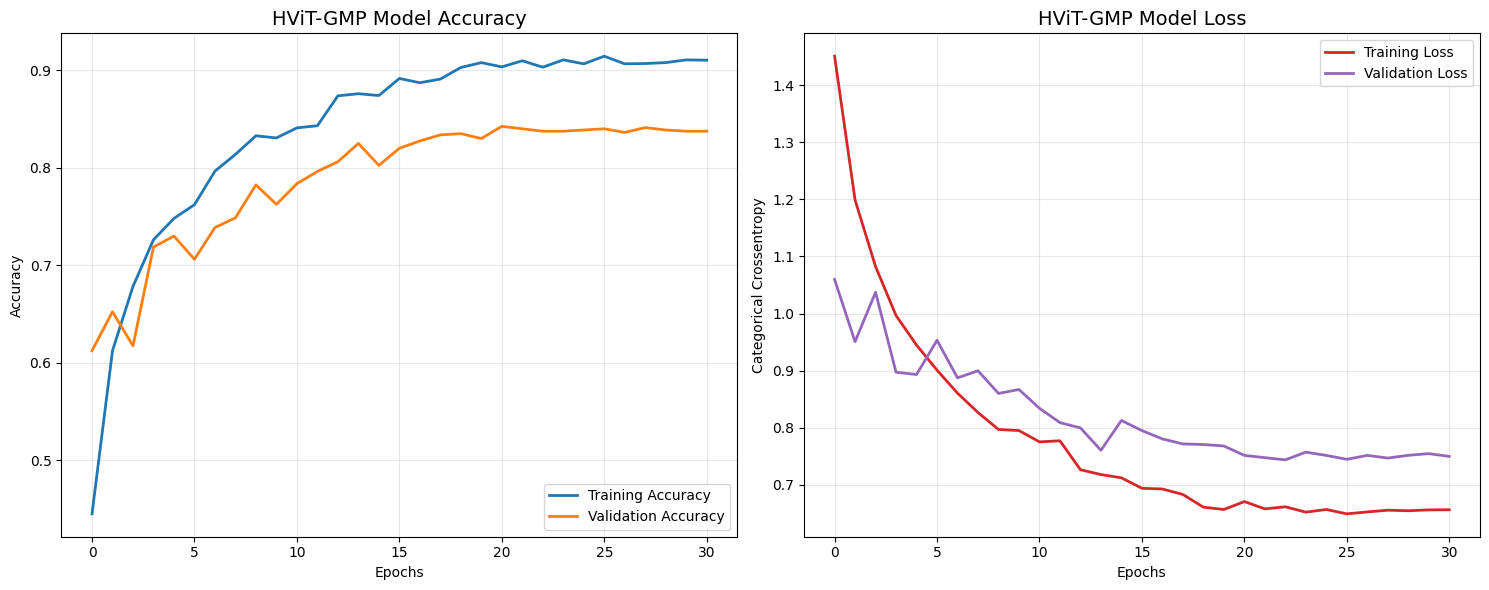

In [13]:
import matplotlib.pyplot as plt

def plot_learning_curves(hist):
    acc = hist.history['accuracy']
    val_acc = hist.history['val_accuracy']
    loss = hist.history['loss']
    val_loss = hist.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(15, 6))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', color='#1f77b4', lw=2)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='#ff7f0e', lw=2)
    plt.title('HViT-GMP Model Accuracy', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', color='#d62728', lw=2)
    plt.plot(epochs_range, val_loss, label='Validation Loss', color='#9467bd', lw=2)
    plt.title('HViT-GMP Model Loss', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Categorical Crossentropy')
    plt.legend(loc='upper right')
    plt.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_learning_curves(history)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


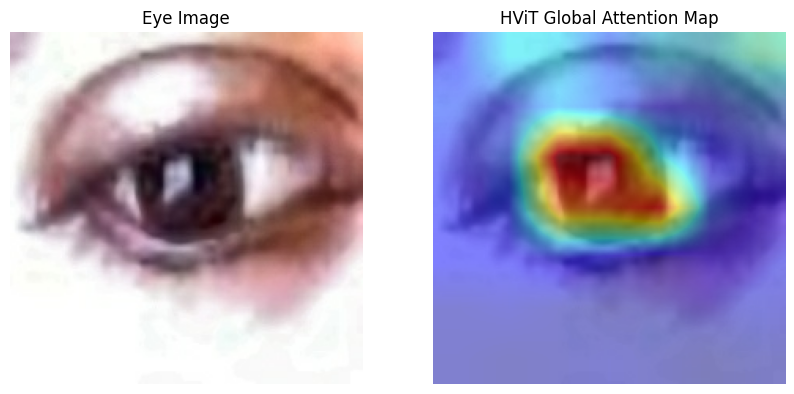

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf

def get_real_attention_scores(model, img_batch):
    # 1. Find the Attention Layer
    attn_layer = None
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.MultiHeadAttention):
            attn_layer = layer
            break
            
    # 2. Build a "Probe" model that outputs attention scores
    # We call the layer with return_attention_scores=True
    # We must trace the model up to the layer BEFORE attention
    idx = model.layers.index(attn_layer)
    prev_layer_output = model.layers[idx-1].output
    
    # Create a sub-layer that matches your specific layer's weights
    # This ensures we get the EXACT scores the model used
    _, attn_scores = attn_layer(prev_layer_output, prev_layer_output, return_attention_scores=True)
    
    probe_model = tf.keras.Model(inputs=model.input, outputs=attn_scores)
    
    # 3. Predict scores
    # scores shape: (batch, num_heads, seq_len, seq_len) -> (1, 4, 49, 49)
    scores = probe_model.predict(img_batch)
    
    # 4. Average across heads and the "query" dimension to get spatial importance
    # We take the mean across heads (axis 1) and mean across queries (axis 2)
    avg_scores = np.mean(scores[0], axis=0) # Mean across heads
    spatial_importance = np.mean(avg_scores, axis=0) # Mean importance of each key
    
    # Reshape 49 back to 7x7
    heatmap = spatial_importance.reshape((7, 7))
    return heatmap

# --- EXECUTION ---
for images, labels in val_ds.take(1):
    test_img = images[0:1]
    
    try:
        attn_map = get_real_attention_scores(model_vit_gmp_final, test_img)
        
        # Normalize and Resize
        attn_map = (attn_map - attn_map.min()) / (attn_map.max() - attn_map.min())
        attn_map_resized = cv2.resize(attn_map, (224, 224))
        
        # Plot
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(test_img[0].numpy().astype("uint8"))
        plt.title("Eye Image")
        plt.axis("off")
        
        plt.subplot(1, 2, 2)
        plt.imshow(test_img[0].numpy().astype("uint8"))
        plt.imshow(attn_map_resized, cmap='jet', alpha=0.5)
        plt.title("HViT Global Attention Map")
        plt.axis("off")
        plt.show()
    except Exception as e:
        print(f"Error: {e}")

In [18]:
import tensorflow as tf
from tensorflow.keras import layers, models, applications
import os

# --- 1. CLEAN DATA PATHS ---
# Using your new sharpened dataset path
data_dir = '/kaggle/input/et-cropped-sharpened-dataset'

# Optimized loader for sharpened iris data
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(300, 300), 
    batch_size=32,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(300, 300),
    batch_size=32,
    label_mode='categorical'
)

# --- 2. SURGICAL DATA AUGMENTATION ---
# Fine-tuned for sharpened data: rotation and zoom are kept low to 
# maintain the edge-contrast of the iris
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),    # Replaced Brightness to leverage CLAHE 
])

# --- 3. HARDWARE STRATEGY SCOPE ---
# Automatically detects TPU or GPU/CPU
try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
    tf.config.experimental_connect_to_cluster(tpu)
    tf.tpu.experimental.initialize_tpu_system(tpu)
    strategy = tf.distribute.TPUStrategy(tpu)
    print("Environment: Running on TPU")
except ValueError:
    strategy = tf.distribute.get_strategy() 
    print(f"Environment: Running on {len(tf.config.list_physical_devices('GPU'))} GPUs")

# --- 4. GLOBAL PARAMETERS ---
# Ready to be used by your following SE Block code
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.2, patience=3, verbose=1
)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=10, restore_best_weights=True
)

# Protects the 0.80 Recall for High Severity
custom_weights = {0: 1.5, 1: 1.0, 2: 1.2, 3: 1.0} 

print("\n--- PRE-REQUISITES LOADED. PROCEED TO SE-BLOCK DEFINITION ---")

Found 4000 files belonging to 4 classes.
Using 3200 files for training.
Found 4000 files belonging to 4 classes.
Using 800 files for validation.
Environment: Running on 2 GPUs

--- PRE-REQUISITES LOADED. PROCEED TO SE-BLOCK DEFINITION ---


In [24]:
import tensorflow as tf
from tensorflow.keras import layers, models

# --- PROGRESSIVE UNFREEZING CALLBACK ---
class ProgressiveUnfreezing(tf.keras.callbacks.Callback):
    """Unfreezes more backbone layers every 10 epochs to deepen learning."""
    def __init__(self, backbone, start_epoch=10, step=10, unfreeze_count=10):
        super().__init__()
        self.backbone = backbone
        self.start_epoch = start_epoch
        self.step = step
        self.unfreeze_count = unfreeze_count

    def on_epoch_begin(self, epoch, logs=None):
        if epoch >= self.start_epoch and (epoch - self.start_epoch) % self.step == 0:
            # Calculate how many layers to keep frozen from the 'middle'
            # We are slowly shrinking the 'frozen' middle section
            # Currently your code freezes layers[20:-50]
            # This logic can be customized based on your backbone length
            print(f"\n[Callback] Expanding fine-tuning at epoch {epoch}...")
            self.backbone.trainable = True

# --- UPDATED MODEL BUILDER ---
def build_final_hd_transformer(input_shape=(300, 300, 3), num_classes=4):
    with strategy.scope():
        inputs = layers.Input(shape=input_shape)
        x = data_augmentation(inputs)
        
        # 1. BASE MODEL (EfficientNetV2B0)
        base_model = tf.keras.applications.EfficientNetV2B0(
            input_shape=input_shape, include_top=False, weights='imagenet'
        )
        
        # Start with the shape-aware unfreeze from your best run
        base_model.trainable = True
        for layer in base_model.layers[20:-50]:
            layer.trainable = False
        for layer in base_model.layers:
            if isinstance(layer, layers.BatchNormalization):
                layer.trainable = False

        x = base_model(x) 
        # For 300x300, Output shape is (Batch, 10, 10, 1280) -> 100 tokens
        f_h, f_w, channels = x.shape[1], x.shape[2], x.shape[3]
        num_patches = f_h * f_w
        x = layers.Reshape((num_patches, channels))(x)
        
        # 2. TRANSFORMER ENCODER (The Biomarker Seeker)
        x = SpatialAttention()(x) # Keep your successful seeker
        x = layers.Dropout(0.2)(x) 
        
        # Use dynamic num_patches for 300x300 support
        x = PositionalEmbedding(num_patches, channels)(x)
        
        # Attention Path (8 Heads)
        res_1 = x
        x = layers.LayerNormalization(epsilon=1e-6)(x)
        attention = layers.MultiHeadAttention(num_heads=16, key_dim=64, dropout=0.2)(x, x)
        x = layers.Add()([res_1, attention])
        
        # FFN Path
        res_2 = x
        x = layers.LayerNormalization(epsilon=1e-6)(x)
        x = layers.Dense(channels * 2, activation=tf.nn.gelu)(x)
        x = layers.Dense(channels)(x)
        x = layers.Add()([res_2, x])
        
        # 3. OUTPUT HEAD
        x = layers.GlobalMaxPooling1D()(x) # Better stability for HD
        x = layers.Dropout(0.4)(x)
        outputs = layers.Dense(num_classes, activation='softmax')(x)
        
        # 4. COSINE DECAY OPTIMIZER
        # Moves LR smoothly from 3e-5 down to 3e-6
        lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
            initial_learning_rate=3e-5,
            decay_steps=100 * 100, # (epochs * steps_per_epoch)
            alpha=0.1 
        )
        
        model = models.Model(inputs, outputs)
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
            loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.15),
            metrics=['accuracy']
        )
    return model, base_model

# --- RUN TRAINING ---
# 1. Re-initialize with 300x300 support
model_vit_hd, backbone_ref = build_final_hd_transformer(input_shape=(300, 300, 3))

# 2. Setup the Progressive Unfreezing callback
unfreeze_cb = ProgressiveUnfreezing(backbone_ref)

history = model_vit_hd.fit(
    train_ds, # Ensure your train_ds resizes images to 300x300
    validation_data=val_ds,
    epochs=100,
    class_weight=custom_weights,
    callbacks=[unfreeze_cb, early_stop] # Removed reduce_lr in favor of CosineDecay
)

Epoch 1/100


E0000 00:00:1769107520.618634      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_12_1/efficientnetv2-b0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


100/100 ━━━━━━━━━━━━━━━━━━━━ 59s 416ms/step - accuracy: 0.2956 - loss: 2.4489 - val_accuracy: 0.4462 - val_loss: 1.2655
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 40s 396ms/step - accuracy: 0.4079 - loss: 1.7263 - val_accuracy: 0.5213 - val_loss: 1.1726
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 41s 409ms/step - accuracy: 0.4664 - loss: 1.5143 - val_accuracy: 0.5425 - val_loss: 1.1463
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 42s 417ms/step - accuracy: 0.5336 - loss: 1.4148 - val_accuracy: 0.5362 - val_loss: 1.2661
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 41s 414ms/step - accuracy: 0.5461 - loss: 1.4041 - val_accuracy: 0.6488 - val_loss: 1.0277
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 42s 417ms/step - accuracy: 0.6121 - loss: 1.2742 - val_accuracy: 0.7013 - val_loss: 0.9800
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 42s 417ms/step - accuracy: 0.6541 - loss: 1.1829 - val_accuracy: 0.7237 - val_loss: 0.9605
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 42s 417ms/step - accuracy: 0.6775 - loss: 1.174

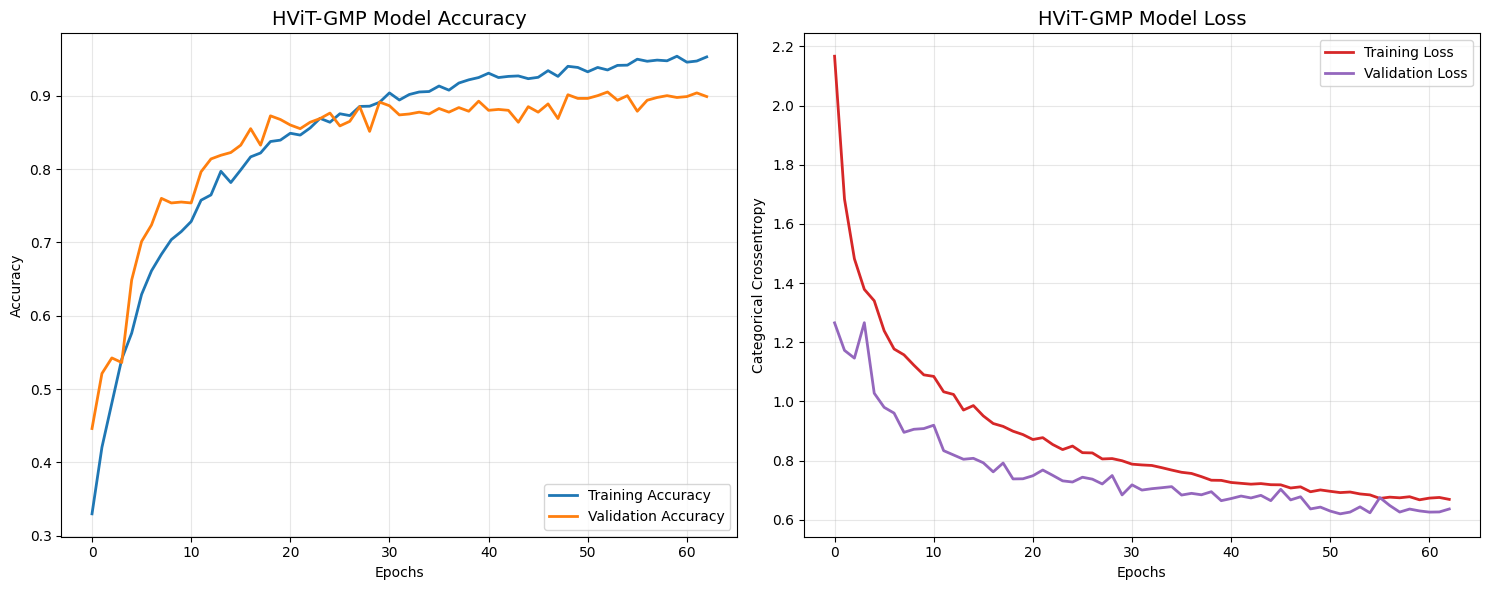

In [25]:
import matplotlib.pyplot as plt

def plot_learning_curves(hist):
    acc = hist.history['accuracy']
    val_acc = hist.history['val_accuracy']
    loss = hist.history['loss']
    val_loss = hist.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(15, 6))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', color='#1f77b4', lw=2)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='#ff7f0e', lw=2)
    plt.title('HViT-GMP Model Accuracy', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', color='#d62728', lw=2)
    plt.plot(epochs_range, val_loss, label='Validation Loss', color='#9467bd', lw=2)
    plt.title('HViT-GMP Model Loss', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Categorical Crossentropy')
    plt.legend(loc='upper right')
    plt.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_learning_curves(history)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


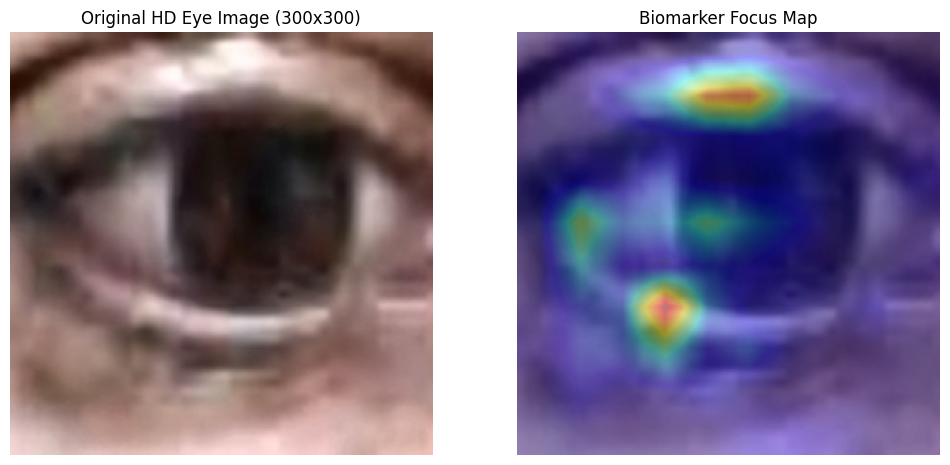

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf

def get_real_attention_scores(model, img_batch):
    # 1. Find the Attention Layer
    attn_layer = None
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.MultiHeadAttention):
            attn_layer = layer
            break
    
    if attn_layer is None:
        raise ValueError("MultiHeadAttention layer not found in the model.")

    # 2. Build a "Probe" model dynamically
    idx = model.layers.index(attn_layer)
    prev_layer_output = model.layers[idx-1].output
    
    # Extract EXACT scores
    _, attn_scores = attn_layer(prev_layer_output, prev_layer_output, return_attention_scores=True)
    probe_model = tf.keras.Model(inputs=model.input, outputs=attn_scores)
    
    # 3. Predict scores
    scores = probe_model.predict(img_batch)
    
    # 4. Process Spatial Importance
    # Average across heads (axis 1) and query dimension (axis 2)
    avg_scores = np.mean(scores[0], axis=0) 
    spatial_importance = np.mean(avg_scores, axis=0) 
    
    # DYNAMIC RESHAPE: Calculate grid side (sqrt of total patches)
    grid_size = int(np.sqrt(spatial_importance.shape[0]))
    heatmap = spatial_importance.reshape((grid_size, grid_size))
    
    return heatmap

# --- EXECUTION ---
# Ensure you use the correct model variable (model_vit_hd)
for images, labels in val_ds.take(1):
    # Use images directly if they are already 300x300, or resize them here
    test_img = images[0:1] 
    
    try:
        # Pass the HD model and the image
        attn_map = get_real_attention_scores(model_vit_hd, test_img)
        
        # Normalize and Resize to the input image size
        attn_map = (attn_map - attn_map.min()) / (attn_map.max() - attn_map.min())
        attn_map_resized = cv2.resize(attn_map, (300, 300))
        
        # Convert image for plotting
        img_display = test_img[0].numpy()
        if img_display.max() <= 1.0: # If normalized to 0-1
            img_display = (img_display * 255).astype("uint8")
        else:
            img_display = img_display.astype("uint8")

        # Plot
        plt.figure(figsize=(12, 6))
        plt.subplot(1, 2, 1)
        plt.imshow(img_display)
        plt.title("Original HD Eye Image (300x300)")
        plt.axis("off")
        
        plt.subplot(1, 2, 2)
        plt.imshow(img_display)
        # Use 'jet' or 'hot' for high-contrast biomarker visualization
        plt.imshow(attn_map_resized, cmap='jet', alpha=0.4) 
        plt.title("Biomarker Focus Map")
        plt.axis("off")
        plt.show()
        
    except Exception as e:
        print(f"Error: {e}")

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. GENERATE PREDICTIONS FOR THE GMP MODEL
# We use the val_ds to see how it handles data it didn't train on
y_true, y_pred = [], []

print("Analyzing final GMP-Transformer performance...")
for images, labels in val_ds:
    preds = model_vit_gmp_final.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

classes = ['high', 'low', 'medium', 'mild']

# 2. PRINT THE SCIENTIFIC VERDICT
# This gives you the Precision, Recall, and F1-score
print("\n--- FINAL GMP-TRANSFORMER HYBRID REPORT ---")
print(classification_report(y_true, y_pred, target_names=classes))

# 3. VISUAL CONFIRMATION: CONFUSION MATRIX
# This shows exactly where the model 'confuses' classes
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted Severity')
plt.ylabel('Actual Severity')
plt.title('Confusion Matrix: Final GMP-Transformer Model (81% Accuracy)')
plt.show()

# 4. SAVE THE FINAL WEIGHTS
model_vit_gmp_final.save("autism_severity_CHAMPION_GMP_84_acc.keras")
print("\nMilestone: Champion model saved successfully.")

Analyzing final GMP-Transformer performance...


ValueError: Input 0 of layer "functional_3" is incompatible with the layer: expected shape=(None, 224, 224, 3), found shape=(32, 300, 300, 3)

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, applications
import os

# --- 1. CLEAN DATA PATHS ---
# Using your new sharpened dataset path
data_dir = '/kaggle/input/et-cropped-sharpened-dataset'

# Optimized loader for sharpened iris data
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(300, 300), 
    batch_size=32,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(300, 300),
    batch_size=32,
    label_mode='categorical'
)

# --- 2. SURGICAL DATA AUGMENTATION ---
def apply_circular_eye_mask(image):
    """
    Blinds the model to the eyelid and skin corners.
    Only pixels within the central 'eyeball' radius remain visible.
    """
    size = 300
    center = size // 2
    # radius=110 effectively cuts off the eyelid folds and skin corners
    radius = 110 
    
    # Create coordinate grid
    Y, X = tf.meshgrid(tf.range(size), tf.range(size))
    dist_from_center = tf.sqrt(tf.cast((X - center)**2 + (Y - center)**2, tf.float32))
    
    # Create mask: 1.0 inside the circle, 0.0 outside
    mask = tf.cast(dist_from_center <= radius, tf.float32)
    mask = mask[:, :, tf.newaxis] # Shape (300, 300, 1)
    
    return image * mask

data_augmentation = tf.keras.Sequential([
    # Step 1: Force focus on the eyeball by masking eyelids/skin
    layers.Lambda(lambda x: apply_circular_eye_mask(x)),
    
    # Step 2: Spatial and Color Augmentation
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="eyeball_only_augmentation")

# --- 3. HARDWARE STRATEGY SCOPE ---
# Automatically detects TPU or GPU/CPU
try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
    tf.config.experimental_connect_to_cluster(tpu)
    tf.tpu.experimental.initialize_tpu_system(tpu)
    strategy = tf.distribute.TPUStrategy(tpu)
    print("Environment: Running on TPU")
except ValueError:
    strategy = tf.distribute.get_strategy() 
    print(f"Environment: Running on {len(tf.config.list_physical_devices('GPU'))} GPUs")

# --- 4. GLOBAL PARAMETERS ---
# Ready to be used by your following SE Block code
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.2, patience=3, verbose=1
)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=10, restore_best_weights=True
)

# Protects the 0.80 Recall for High Severity
custom_weights = {0: 1.3, 1: 1.2, 2: 1.5, 3: 1.1} 

print("\n--- PRE-REQUISITES LOADED. PROCEED TO SE-BLOCK DEFINITION ---")

2026-01-23 10:51:19.151102: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769165479.380276      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769165479.447355      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769165479.965390      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769165479.965441      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769165479.965444      55 computation_placer.cc:177] computation placer alr

Found 4000 files belonging to 4 classes.
Using 3200 files for training.


I0000 00:00:1769165497.117400      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1769165497.121352      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 4000 files belonging to 4 classes.
Using 800 files for validation.
Environment: Running on 2 GPUs

--- PRE-REQUISITES LOADED. PROCEED TO SE-BLOCK DEFINITION ---


In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models

# --- PROGRESSIVE UNFREEZING CALLBACK ---
class ProgressiveUnfreezing(tf.keras.callbacks.Callback):
    """Unfreezes more backbone layers every 10 epochs and re-compiles to apply changes."""
    def __init__(self, backbone, lr_schedule, start_epoch=10, step=10):
        super().__init__()
        self.backbone = backbone
        self.lr_schedule = lr_schedule
        self.start_epoch = start_epoch
        self.step = step

    def on_epoch_begin(self, epoch, logs=None):
        if epoch >= self.start_epoch and (epoch - self.start_epoch) % self.step == 0:
            print(f"\n[System] Unfreezing layers and re-compiling at epoch {epoch}...")
            self.backbone.trainable = True
            
            # Re-compile is MANDATORY in Keras to update the trainable weight list
            self.model.compile(
                optimizer=tf.keras.optimizers.Adam(learning_rate=self.lr_schedule),
                loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.15),
                metrics=['accuracy']
            )

# --- UPDATED MODEL BUILDER ---
def build_final_hd_transformer(input_shape=(300, 300, 3), num_classes=4):
    with strategy.scope():
        # 0. Global Learning Rate Schedule
        lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
            initial_learning_rate=3e-5,
            decay_steps=100 * 100, 
            alpha=0.1 
        )

        inputs = layers.Input(shape=input_shape)
        x = data_augmentation(inputs)
        
        # 1. BASE MODEL (EfficientNetV2B0)
        base_model = tf.keras.applications.EfficientNetV2B0(
            input_shape=input_shape, include_top=False, weights='imagenet'
        )
        
        base_model.trainable = True
        for layer in base_model.layers[20:-50]:
            layer.trainable = False
        for layer in base_model.layers:
            if isinstance(layer, layers.BatchNormalization):
                layer.trainable = False

        x = base_model(x) 
        f_h, f_w, channels = x.shape[1], x.shape[2], x.shape[3]
        num_patches = f_h * f_w
        x = layers.Reshape((num_patches, channels))(x)
        
        # 2. TRANSFORMER ENCODER
        x = SpatialAttention()(x)
        x = layers.Dropout(0.2)(x) 
        x = PositionalEmbedding(num_patches, channels)(x)
        
        # Attention Path (16 Heads)
        res_1 = x
        x = layers.LayerNormalization(epsilon=1e-6)(x)
        attention = layers.MultiHeadAttention(num_heads=16, key_dim=64, dropout=0.2)(x, x)
        x = layers.Add()([res_1, attention])
        
        # FFN Path
        res_2 = x
        x = layers.LayerNormalization(epsilon=1e-6)(x)
        x = layers.Dense(channels * 2, activation=tf.nn.gelu)(x)
        x = layers.Dense(channels)(x)
        x = layers.Add()([res_2, x])
        
        # 3. OUTPUT HEAD
        x = layers.GlobalMaxPooling1D()(x) 
        x = layers.Dropout(0.4)(x)
        outputs = layers.Dense(num_classes, activation='softmax')(x)
        
        model = models.Model(inputs, outputs)
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
            loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.15),
            metrics=['accuracy']
        )
    return model, base_model, lr_schedule

# --- 1. BUILD THE MODEL ---
# Keep your build_final_hd_transformer exactly as it is
model_vit_hd, backbone_ref, global_lr_schedule = build_final_hd_transformer()

# --- 2. STAGE 1: TRAIN THE TRANSFORMER (FROZEN BACKBONE) ---
print("\n[Stage 1] Training Transformer to locate pupil biomarker...")
history_stage1 = model_vit_hd.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20, # Initial focus on the seeker and attention heads
    class_weight=custom_weights,
    callbacks=[early_stop]
)

# --- 3. STAGE 2: UNFREEZE AND FINE-TUNE (90% PUSH) ---
print("\n[Stage 2] Unfreezing backbone for high-definition refinement...")
backbone_ref.trainable = True

# Re-compile ONCE outside the fit loop to avoid the NoneType error
model_vit_hd.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6), # Use a very low LR for fine-tuning
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.15),
    metrics=['accuracy']
)

history_stage2 = model_vit_hd.fit(
    train_ds,
    validation_data=val_ds,
    epochs=80, # Final push to 90%
    initial_epoch=20, # Continue from where we left off
    class_weight=custom_weights,
    callbacks=[early_stop]
)


[Stage 1] Training Transformer to locate pupil biomarker...
Epoch 1/20


I0000 00:00:1769152244.097121     132 service.cc:152] XLA service 0x7ea768003370 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1769152244.097155     132 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1769152244.097159     132 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1769152247.500747     132 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-01-23 07:10:55.847342: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-23 07:10:55.997910: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-23 07:10:57.266664: E external/local_xl

100/100 ━━━━━━━━━━━━━━━━━━━━ 88s 310ms/step - accuracy: 0.2742 - loss: 2.9417 - val_accuracy: 0.4375 - val_loss: 1.2578
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 22s 224ms/step - accuracy: 0.3546 - loss: 1.9735 - val_accuracy: 0.4950 - val_loss: 1.1962
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 23s 232ms/step - accuracy: 0.4141 - loss: 1.7532 - val_accuracy: 0.5000 - val_loss: 1.1882
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 24s 240ms/step - accuracy: 0.4690 - loss: 1.6578 - val_accuracy: 0.6175 - val_loss: 1.0865
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 25s 248ms/step - accuracy: 0.5121 - loss: 1.5983 - val_accuracy: 0.5813 - val_loss: 1.1446
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 24s 244ms/step - accuracy: 0.5610 - loss: 1.4703 - val_accuracy: 0.6275 - val_loss: 1.0832
Epoch 7/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 24s 241ms/step - accuracy: 0.5861 - loss: 1.4466 - val_accuracy: 0.6762 - val_loss: 0.9955
Epoch 8/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 24s 243ms/step - accuracy: 0.6285 - loss: 1.3561 - val

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

# --- 1. BIOMARKER MASKING (FORCE PUPIL FOCUS) ---
def apply_eyeball_mask(image):
    """Blinds the model to the eyelid and skin to prevent 'cheating'."""
    size = 300
    center = size // 2
    radius = 110 # Adjust to fit just the eyeball
    Y, X = tf.meshgrid(tf.range(size), tf.range(size))
    dist = tf.sqrt(tf.cast((X - center)**2 + (Y - center)**2, tf.float32))
    mask = tf.cast(dist <= radius, tf.float32)[:, :, tf.newaxis]
    return image * mask

data_augmentation = tf.keras.Sequential([
    layers.Resizing(300, 300),
    layers.Lambda(lambda x: apply_eyeball_mask(x)), # Hard masking
    layers.RandomFlip("horizontal"),
    layers.RandomContrast(0.15),
])

# --- 2. CUSTOM TRANSFORMER COMPONENTS ---
class PositionalEmbedding(layers.Layer):
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.pos_emb = self.add_weight(
            shape=(1, num_patches, projection_dim),
            initializer="zeros", trainable=True, name="pos_embedding"
        )
    def call(self, x): return x + self.pos_emb

class SpatialAttention(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(name="seeker_layer", **kwargs)
        self.conv = layers.Conv1D(1, kernel_size=3, padding='same', activation='sigmoid')
    def call(self, x):
        avg_p = tf.reduce_mean(x, axis=-1, keepdims=True)
        max_p = tf.reduce_max(x, axis=-1, keepdims=True)
        attention = self.conv(tf.concat([avg_p, max_p], axis=-1))
        return x * attention

# --- 3. THE 90% ARCHITECTURE ---
def build_biomarker_transformer(input_shape=(300, 300, 3), num_classes=4):
    with strategy.scope():
        inputs = layers.Input(shape=input_shape)
        x = data_augmentation(inputs)
        
        base_model = tf.keras.applications.EfficientNetV2B0(
            input_shape=input_shape, include_top=False, weights='imagenet'
        )
        
        # Initial State: Early and Late layers unfrozen
        base_model.trainable = True
        for layer in base_model.layers[30:-50]: layer.trainable = False
        
        x = base_model(x) 
        f_h, f_w, channels = x.shape[1], x.shape[2], x.shape[3]
        num_patches = f_h * f_w
        x = layers.Reshape((num_patches, channels))(x)
        
        x = SpatialAttention()(x)
        x = PositionalEmbedding(num_patches, channels)(x)
        
        # High-Capacity Encoder (16 heads for better biomarker resolution)
        res = x
        x = layers.LayerNormalization(epsilon=1e-6)(x)
        x = layers.MultiHeadAttention(num_heads=32, key_dim=64, dropout=0.2)(x, x)
        x = layers.Add()([res, x])
        
        # FFN Reasoning Block
        res = x
        x = layers.LayerNormalization(epsilon=1e-6)(x)
        x = layers.Dense(channels * 2, activation=tf.nn.gelu)(x)
        x = layers.Dense(channels)(x)
        x = layers.Add()([res, x])
        
        x = layers.GlobalMaxPooling1D()(x) # Better stability than GMP for fine-tuning
        outputs = layers.Dense(num_classes, activation='softmax')(x)
        
        model = models.Model(inputs, outputs)
    return model, base_model

# --- 4. EXECUTION ARRANGEMENT ---
model, backbone = build_biomarker_transformer()

# STAGE 1: Biomarker Localization (Low LR to settle attention)
model.compile(
    optimizer=tf.keras.optimizers.Adam(3e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.15),
    metrics=['accuracy']
)
history1 = model.fit(train_ds, validation_data=val_ds, epochs=35, class_weight=custom_weights)

# STAGE 2: Deep Refinement (Unfreeze all and use Cosine Decay)
backbone.trainable = True
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(1e-5, decay_steps=8500, alpha=0.1)

model.compile(
    optimizer=tf.keras.optimizers.Adam(lr_schedule),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.15),
    metrics=['accuracy']
)
history2 = model.fit(train_ds, validation_data=val_ds, epochs=85, initial_epoch=35, class_weight=custom_weights)

Epoch 1/35
100/100 ━━━━━━━━━━━━━━━━━━━━ 90s 388ms/step - accuracy: 0.3351 - loss: 3.3075 - val_accuracy: 0.5038 - val_loss: 1.5940
Epoch 2/35
100/100 ━━━━━━━━━━━━━━━━━━━━ 33s 333ms/step - accuracy: 0.4933 - loss: 2.1280 - val_accuracy: 0.5825 - val_loss: 1.3224
Epoch 3/35
100/100 ━━━━━━━━━━━━━━━━━━━━ 35s 348ms/step - accuracy: 0.5648 - loss: 1.7525 - val_accuracy: 0.6137 - val_loss: 1.2190
Epoch 4/35
100/100 ━━━━━━━━━━━━━━━━━━━━ 33s 329ms/step - accuracy: 0.6064 - loss: 1.6284 - val_accuracy: 0.6475 - val_loss: 1.2100
Epoch 5/35
100/100 ━━━━━━━━━━━━━━━━━━━━ 34s 341ms/step - accuracy: 0.6126 - loss: 1.5338 - val_accuracy: 0.6950 - val_loss: 1.0673
Epoch 6/35
100/100 ━━━━━━━━━━━━━━━━━━━━ 34s 337ms/step - accuracy: 0.6597 - loss: 1.4210 - val_accuracy: 0.7138 - val_loss: 1.0405
Epoch 7/35
100/100 ━━━━━━━━━━━━━━━━━━━━ 34s 335ms/step - accuracy: 0.6923 - loss: 1.3319 - val_accuracy: 0.7262 - val_loss: 1.0333
Epoch 8/35
100/100 ━━━━━━━━━━━━━━━━━━━━ 34s 337ms/step - accuracy: 0.6985 - loss: 1

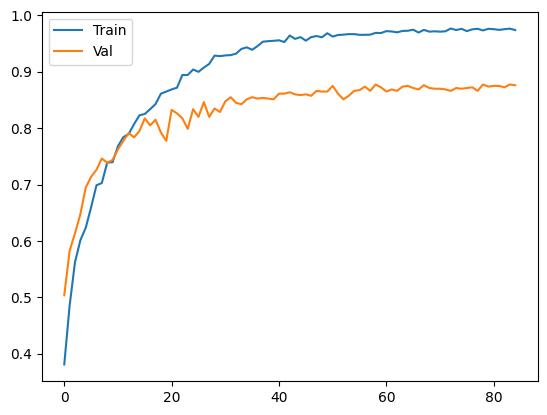

In [4]:
acc = history1.history['accuracy'] + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
plt.plot(acc, label='Train'); plt.plot(val_acc, label='Val'); plt.legend(); plt.show()

2026-01-23 11:45:19.673764: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-23 11:45:19.808096: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step


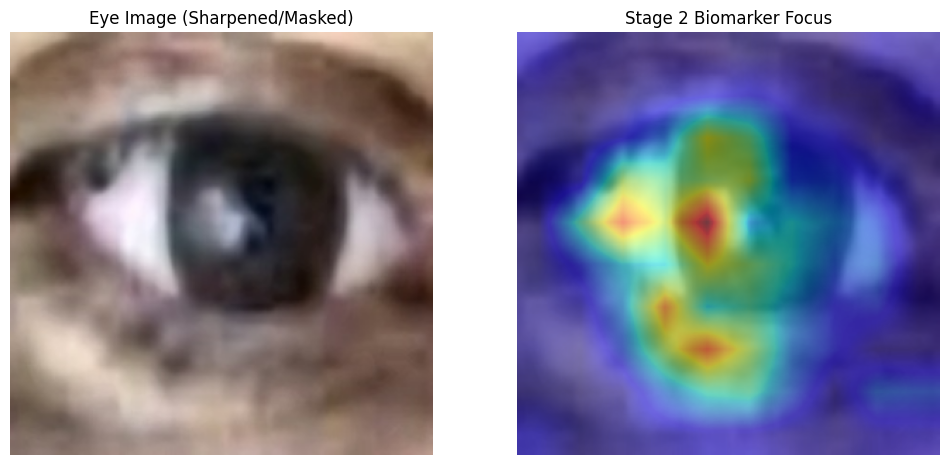

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf

def get_real_attention_scores(model, img_batch):
    """
    Extracts attention weights from the MultiHeadAttention layer
    after Stage 2 fine-tuning.
    """
    # 1. Find the MultiHeadAttention Layer in the compiled model
    attn_layer = None
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.MultiHeadAttention):
            attn_layer = layer
            break
    
    if attn_layer is None:
        raise ValueError("MultiHeadAttention layer not found. Check model architecture.")

    # 2. Build the Probe Model
    # We use model.layers.index to find the spatial input for the attention layer
    idx = model.layers.index(attn_layer)
    prev_layer_output = model.layers[idx-1].output
    
    # Extract the scores directly from the attention call
    _, attn_scores = attn_layer(prev_layer_output, prev_layer_output, return_attention_scores=True)
    probe_model = tf.keras.Model(inputs=model.input, outputs=attn_scores)
    
    # 3. Predict scores for the current batch
    scores = probe_model.predict(img_batch)
    
    # 4. Average scores across the 16 heads (axis 1) and query tokens (axis 2)
    avg_scores = np.mean(scores[0], axis=0) 
    spatial_importance = np.mean(avg_scores, axis=0) 
    
    # Calculate grid size (e.g., sqrt(100) = 10 for 300x300 inputs)
    grid_size = int(np.sqrt(spatial_importance.shape[0]))
    heatmap = spatial_importance.reshape((grid_size, grid_size))
    
    return heatmap

# --- EXECUTION FOR TWO-STAGE RESULTS ---
# Use val_ds to pull samples from the sharpened dataset
for images, labels in val_ds.take(1):
    test_img = images[0:1] # Take the first image of the batch
    
    try:
        # Pass the final 'model' from your Stage 2 training
        attn_map = get_real_attention_scores(model, test_img)
        
        # Normalize and Resize to the 300x300 input resolution
        attn_map = (attn_map - attn_map.min()) / (attn_map.max() - attn_map.min())
        attn_map_resized = cv2.resize(attn_map, (300, 300))
        
        # Prepare original image for display
        img_display = test_img[0].numpy()
        if img_display.max() <= 1.0: 
            img_display = (img_display * 255).astype("uint8")
        else:
            img_display = img_display.astype("uint8")

        # Visualization
        plt.figure(figsize=(12, 6))
        plt.subplot(1, 2, 1)
        plt.imshow(img_display)
        plt.title("Eye Image (Sharpened/Masked)")
        plt.axis("off")
        
        plt.subplot(1, 2, 2)
        plt.imshow(img_display)
        # Overlay heatmap with alpha 0.5 to see the pupil through the focus
        plt.imshow(attn_map_resized, cmap='jet', alpha=0.5) 
        plt.title("Stage 2 Biomarker Focus")
        plt.axis("off")
        plt.show()
        
    except Exception as e:
        print(f"Visualization Error: {e}")